# **MÓDULO 14 - Exercício**
# Pré Processamento dos Dados - A primeira etapa Pré Modelagem

Para nossa atividade usaremos uma base de churn também, porém essa base não diz respeito a serviços bancários e sim serviços de internet, telefone e tv - Telecomunicação.

Vamos realizar aqui as etapas de limpeza e tratamento de dados vistos durante a aula, porém aplicados a essa base nova.

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [8]:
#Lembrem-se sempre de alterar a importação dos dados de acordo com o diretório de vocês.
df = pd.read_csv("CHURN_TELECON_MOD08_TAREFA.csv", delimiter=';')

df.head(10)

,customerID,Genero,Idoso,Casado,Dependents,Tempo_como_Cliente,PhoneService,Servico_Internet,Servico_Seguranca,Suporte_Tecnico,StreamingTV,Tipo_Contrato,PaymentMethod,Pagamento_Mensal,Total_Pago,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,DSL,No,No,No,Month-to-month,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,DSL,Yes,No,No,One year,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,DSL,Yes,No,No,Month-to-month,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,DSL,Yes,Yes,No,One year,Bank transfer (automatic),NaN,1840.75,No
4,9237-HQITU,NaN,0,No,No,2,Yes,Fiber optic,No,No,No,Month-to-month,Electronic check,NaN,151.65,Yes
5,9305-CDSKC,NaN,0,No,No,8,Yes,Fiber optic,No,No,Yes,Month-to-month,Electronic check,NaN,820.50,NaN
6,1452-KIOVK,NaN,0,No,Yes,22,Yes,Fiber optic,No,No,Yes,Month-to-month,Credit card (automatic),NaN,1949.40,NaN
7,6713-OKOMC,NaN,0,No,No,10,No,DSL,Yes,No,No,Month-to-month,Mailed check,NaN,301.90,NaN
8,7892-POOKP,NaN,0,Yes,No,28,Yes,Fiber optic,No,Yes,Yes,Month-to-month,Electronic check,NaN,3046.05,NaN
9,6388-TABGU,NaN,0,No,Yes,62,Yes,dsl,Yes,No,No,One year,Bank transfer (automatic),NaN,3487.95,NaN


Legenda dos dados:

*   **CustomerID** : Esse é o ID único de cada cliente nosso da rede de produtos de telecomunicação.

*   **Genero** : O genero dos nossos clientes.

*   **Idoso** : Se nosso cliente tem acima de 60 anos ou não. (Sim = 1 | Não = 0)

*   **Casado** : Se nosso cliente é casado ou não.

*   **Dependents** : Se cliente tem dependentes.

*   **Tempo_como_Cliente** : Tempo em meses que nosso cliente está com a nossa empresa.

*   **PhoneService** : Se ele contratou serviço telefônico com a nossa empresa.

*   **Servico_Internet** : Qual o tipo de serviço de internet contratado.

*   **Servico_Seguranca** : Se ele contratou serviço de segurança com a nossa empresa.

*   **Suporte_Tecnico** : Se já acionou o suporte técnico.

*   **StreamingTV** : Se ele contratou serviço de streaming para TV.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **Tipo_Contrato** : Qual o tipo de contrato dos nossos clientes, se era mensal, anual etc.

*   **PaymentMethod** : Forma de Pagamento.

*   **Pagamento_Mensal** : Quanto o cliente pagava mensalmente.

*   **Total_Pago** : Total já pago pelo cliente para nossa companhia.

*   **Churn** : Nossa coluna mais importante, se nosso cliente nos abandonou ou não.




# 1 - Carregue a base, verifique se os tipos de dados estão de acordo com cada coluna e caso não estejam realize a transformação dos tipos de dados.

In [12]:
#seu código aqui
df.dtypes

customerID             object
Genero                 object
Idoso                   int64
Casado                 object
Dependents             object
Tempo_como_Cliente      int64
PhoneService           object
Servico_Internet       object
Servico_Seguranca      object
Suporte_Tecnico        object
StreamingTV            object
Tipo_Contrato          object
PaymentMethod          object
Pagamento_Mensal      float64
Total_Pago            float64
Churn                  object
dtype: object

In [14]:
df['Idoso'] = df['Idoso'].astype(bool)
df['Casado'] = df['Casado'].astype(bool)
df['Dependents'] = df['Dependents'].astype(bool)
df['PhoneService'] = df['PhoneService'].astype(bool)
df['Servico_Seguranca'] = df['Servico_Seguranca'].astype(bool)
df['StreamingTV'] = df['StreamingTV'].astype(bool)

# 2 - Esse exercício faremos por etapas:
### A) Verifique se temos colunas com dados faltantes e traga a % dos dados faltantes por coluna.

In [17]:
#seu código aqui
df.isnull().sum()

customerID              0
Genero                 12
Idoso                   0
Casado                  0
Dependents              0
Tempo_como_Cliente      0
PhoneService            0
Servico_Internet        0
Servico_Seguranca       0
Suporte_Tecnico         0
StreamingTV             0
Tipo_Contrato           0
PaymentMethod           0
Pagamento_Mensal      325
Total_Pago              0
Churn                   5
dtype: int64

In [19]:
#Descobrir a porcentagem
(df.isnull().sum() / len(df)) * 100

customerID             0.00
Genero                 0.48
Idoso                  0.00
Casado                 0.00
Dependents             0.00
Tempo_como_Cliente     0.00
PhoneService           0.00
Servico_Internet       0.00
Servico_Seguranca      0.00
Suporte_Tecnico        0.00
StreamingTV            0.00
Tipo_Contrato          0.00
PaymentMethod          0.00
Pagamento_Mensal      13.00
Total_Pago             0.00
Churn                  0.20
dtype: float64

### B) Exclua nessa etapa as linhas das colunas com dados faltantes que você analisar que esse método é o ideal. Justifique o motivo de estar excluindo essas linhas.

Como Churn é a variável resposta e possui pouquíssimos valores nulos, a exclusão das linhas não impacta a base e evita erros na modelagem.

In [23]:
df.dropna(subset=['Churn'], inplace=True)

A moda representa o valor mais frequente da variável categórica, sendo a melhor escolha para manter o padrão predominante dos dados.

In [26]:
df['Genero'] = df['Genero'].fillna(df['Genero'].mode()[0])


In [28]:
df.isnull().sum()

customerID              0
Genero                  0
Idoso                   0
Casado                  0
Dependents              0
Tempo_como_Cliente      0
PhoneService            0
Servico_Internet        0
Servico_Seguranca       0
Suporte_Tecnico         0
StreamingTV             0
Tipo_Contrato           0
PaymentMethod           0
Pagamento_Mensal      320
Total_Pago              0
Churn                   0
dtype: int64

### C) Nessa etapa substitua pela média, mediana ou moda as linhas das colunas com valores faltantes que você analisou e entendeu que esse era o melhor método. Não se esqueça de justificar sua escolha.

**Dica variáveis numéricas:** Não se esqueça de verificar a distrbuição dos dados, média e mediana.

**Dica variáveis categóricas:** Caso precise substituir uma variável categórica utilize um gráfico de barras para verificar a que mais aparece e utilizar ela na substituição.
Ou você pode optar por excluir a coluna, mas justifique sua escolha.

Caso opte por substituir você pode utilizar a função fillna:
df['SUACOLUNA'].fillna("VALOR QUE SUBSTITUIRA O NULO", inplace=True)
Ela funcionará como a replace.

In [33]:
#seu código aqui
df['Pagamento_Mensal'].describe()

count    2175.000000
mean       65.607563
std        29.931520
min        18.400000
25%        39.500000
50%        71.450000
75%        90.250000
max       118.650000
Name: Pagamento_Mensal, dtype: float64

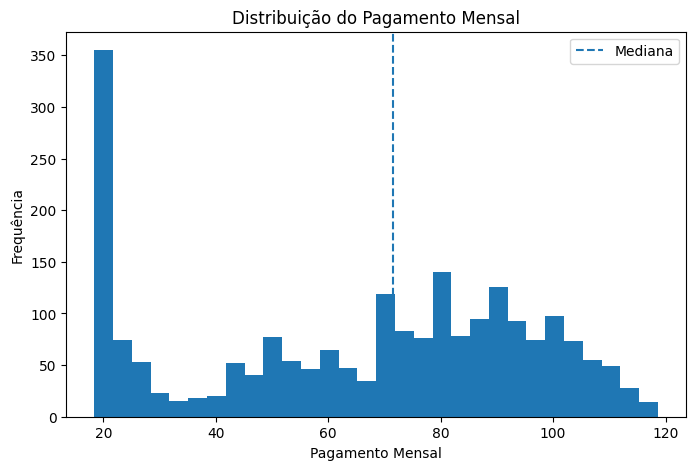

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['Pagamento_Mensal'], bins=30)
plt.axvline(df['Pagamento_Mensal'].median(), linestyle='--', label='Mediana')
plt.title('Distribuição do Pagamento Mensal')
plt.xlabel('Pagamento Mensal')
plt.ylabel('Frequência')
plt.legend()
plt.show()

O gráfico mostra a distribuição dos valores de pagamento mensal dos clientes. Observa-se uma assimetria nos dados, o que justifica o uso da mediana para substituição dos valores faltantes, por ser menos sensível a valores extremos.

In [38]:
df['Pagamento_Mensal'] = df['Pagamento_Mensal'].fillna(
    df['Pagamento_Mensal'].median()
)

In [40]:
df.isnull().sum()

customerID            0
Genero                0
Idoso                 0
Casado                0
Dependents            0
Tempo_como_Cliente    0
PhoneService          0
Servico_Internet      0
Servico_Seguranca     0
Suporte_Tecnico       0
StreamingTV           0
Tipo_Contrato         0
PaymentMethod         0
Pagamento_Mensal      0
Total_Pago            0
Churn                 0
dtype: int64

# 3 - Verifique se encontramos valores digitados incorretamente, ou com letras maiusculas ou minusculas, ou até mesmo mesmos valores porém escritos de forma dirente e corrija.

In [43]:
#seu código aqui
df.select_dtypes(include='object').nunique()


customerID          2495
Genero                 5
Servico_Internet       4
Suporte_Tecnico        3
Tipo_Contrato          3
PaymentMethod          4
Churn                  2
dtype: int64

In [45]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()


In [47]:
df.select_dtypes(include='object').head()


,customerID,Genero,Servico_Internet,Suporte_Tecnico,Tipo_Contrato,PaymentMethod,Churn
0,7590-vhveg,female,dsl,no,month-to-month,electronic check,no
1,5575-gnvde,male,dsl,no,one year,mailed check,no
2,3668-qpybk,male,dsl,no,month-to-month,mailed check,yes
3,7795-cfocw,male,dsl,yes,one year,bank transfer (automatic),no
4,9237-hqitu,male,fiber optic,no,month-to-month,electronic check,yes


# [EXTRA] 4 - Caso deseje, para manter um padrão na sua base, renomeie as colunas ou deixando em português, ou inglês.

In [50]:
df.rename(columns={
    'customerID': 'id_cliente',
    'Genero': 'genero',
    'Idoso': 'idoso',
    'Casado': 'casado',
    'Dependents': 'possui_dependentes',
    'Tempo_como_Cliente': 'tempo_como_cliente',
    'PhoneService': 'servico_telefone',
    'Servico_Internet': 'servico_internet',
    'Servico_Seguranca': 'servico_seguranca',
    'Suporte_Tecnico' : 'suporte_tecnico',
    'StreamingTV' : 'streaming',
    'Tipo_Contrato' : 'tipo_contrato',
    'PaymentMethod' : 'metodo_pagamento',
    'Pagamento_Mensal' : 'pagamento_mensal',
    'Total_Pago' : 'total_pago',
    'Churn': 'churn'
}, inplace=True)


In [52]:
df.columns


Index(['id_cliente', 'genero', 'idoso', 'casado', 'possui_dependentes',
       'tempo_como_cliente', 'servico_telefone', 'servico_internet',
       'servico_seguranca', 'suporte_tecnico', 'streaming', 'tipo_contrato',
       'metodo_pagamento', 'pagamento_mensal', 'total_pago', 'churn'],
      dtype='object')

In [56]:
#Salvar o df em csv para ser importado em outro notebook
df.to_csv('churn_tratado_m14.csv', index=False)